## SVM
- Banknote Authentication 데이터셋은 진짜 지폐와 위조 지폐 이미지를 복잡하고 일그러진 이미지(또는 신호)를 작은 물결 모양의 조각(Wavelet)들로 쪼개서,  
  눈에 잘 안 보이는 패턴 특징을 뽑아내는 기술 웨이블릿 변환하여 추출한 4가지 연속형 특성으로 구성된 이진 분류 데이터입니다.

[Banknote Authentication 데이터셋](https://archive.ics.uci.edu/dataset/267/banknote+authentication)

### 데이터셋 컬럼 명세 (Metadata)

| 컬럼명 | 데이터 타입 | 데이터 범위 (Min ~ Max) | 구분 | 설명 |
| :--- | :---: | :---: | :---: | :--- |
| **variance** | `float64` | -7.0421 ~ 6.8248 | Feature | 웨이블릿 변환 이미지의 변량 (지폐 선명도 및 질감 변동 폭) |
| **skewness** | `float64` | -13.7731 ~ 12.9516 | Feature | 웨이블릿 변환 이미지의 왜도 (명암 분포의 비대칭성) |
| **curtosis** | `float64` | -5.2861 ~ 17.9274 | Feature | 웨이블릿 변환 이미지의 첨도 (명암 분포의 돌출도) |
| **entropy** | `float64` | -8.5801 ~ 2.4495 | Feature | 이미지 정보의 엔트로피 (무작위성 및 정보 복잡도) |
| **class** | `int64` | 0 또는 1 | Target | 지폐 진위 여부 (**0**: 진짜 지폐 / **1**: 위조 지폐) |

### 데이터셋의 상세 설명
- variance (변량): 미세 질감이 얼마나 일정하게 오르락내리락하는가? (지폐 질감 선명도)
- skewness (왜도): 명암이나 잉크 굵기 패턴이 한쪽으로 쏠려 있는가?
- curtosis (첨도): 잉크 경계선이나 미세 선들이 얼마나 뾰족하고 매섭게 인쇄되었는가?
- entropy (엔트로피): 미세 패턴이 얼마나 복잡하고 무작위적인가?

In [1]:
import os
import sklearn
from sklearn.datasets import load_iris
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import platform

sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [4]:
base_path = r"C:\kdt_0900_osh\ml\resource\datasets"
file_name = r"banknote_authentication.csv"

file_path = os.path.join(base_path,file_name)

bank_df = pd.read_csv(file_path)

In [5]:
bank_df

,variance,skewness,curtosis,entropy,class
0,3.62160,8.66610,-2.8073,-0.44699,0
1,4.54590,8.16740,-2.4586,-1.46210,0
2,3.86600,-2.63830,1.9242,0.10645,0
3,3.45660,9.52280,-4.0112,-3.59440,0
4,0.32924,-4.45520,4.5718,-0.98880,0
...,...,...,...,...,...
1367,0.40614,1.34920,-1.4501,-0.55949,1
1368,-1.38870,-4.87730,6.4774,0.34179,1
1369,-3.75030,-13.45860,17.5932,-2.77710,1
1370,-3.56370,-8.38270,12.3930,-1.28230,1


## 1단계. 데이터 탐색

In [6]:
bank_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [10]:
bank_df.describe()

,variance,skewness,curtosis,entropy,class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [8]:
bank_df[bank_df["class"] == 1].describe()

,variance,skewness,curtosis,entropy,class
count,610.000000,610.000000,610.000000,610.000000,610.0
mean,-1.868443,-0.993576,2.148271,-1.246641,1.0
std,1.881183,5.404884,5.261811,2.070984,0.0
min,-7.042100,-13.773100,-5.286100,-7.588700,1.0
25%,-3.061450,-5.810025,-1.357500,-2.458375,1.0
50%,-1.806100,0.172775,0.373720,-0.661650,1.0
75%,-0.541770,3.189275,5.626350,0.341790,1.0
max,2.391700,9.601400,17.927400,2.135300,1.0


In [9]:
bank_df[bank_df["class"] == 0].describe()

,variance,skewness,curtosis,entropy,class
count,762.000000,762.000000,762.000000,762.000000,762.0
mean,2.276686,4.256627,0.796718,-1.147640,0.0
std,2.019348,5.138792,3.239894,2.125077,0.0
min,-4.285900,-6.932100,-4.941700,-8.548200,0.0
25%,0.883345,0.450063,-1.709700,-2.228250,0.0
50%,2.553100,5.668800,0.700605,-0.552380,0.0
75%,3.884450,8.691975,2.652925,0.423257,0.0
max,6.824800,12.951600,8.829400,2.449500,0.0


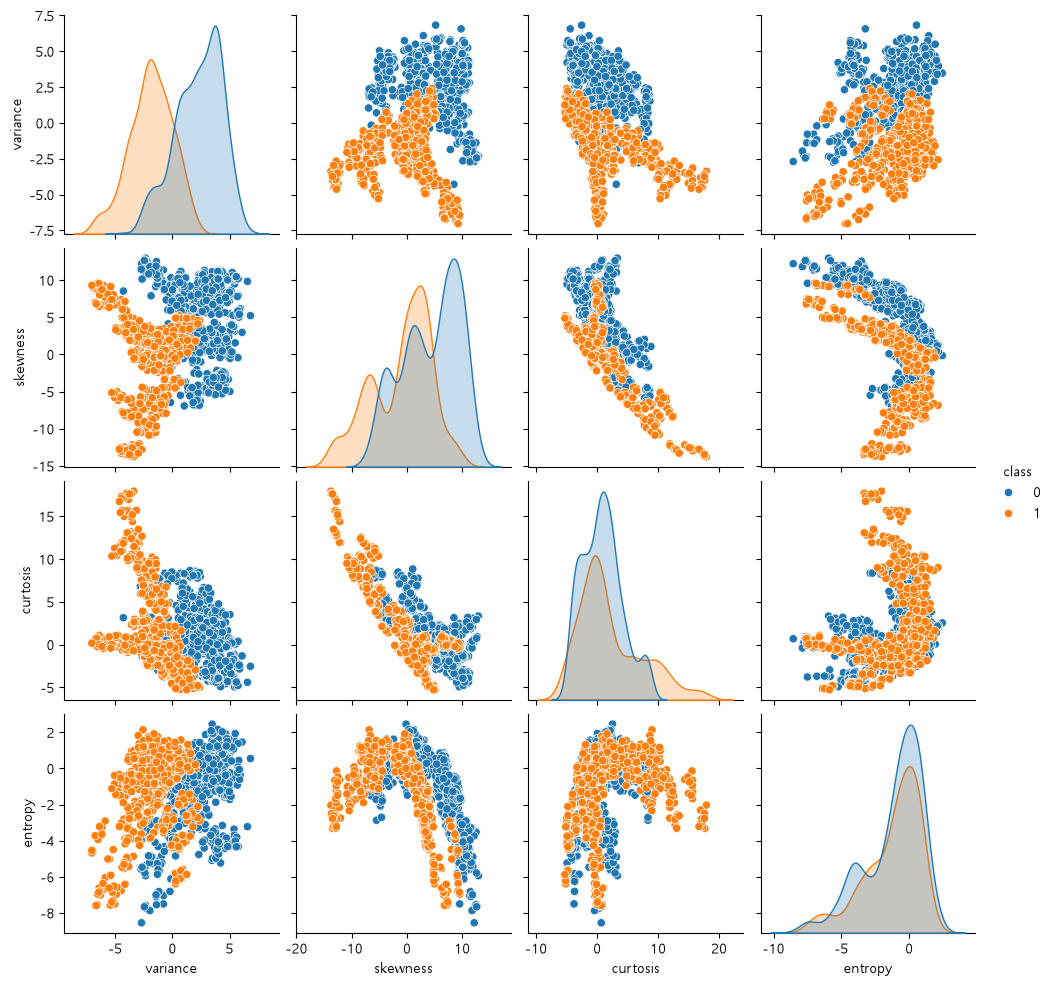

In [14]:
sns.pairplot(bank_df, hue="class")
plt.show()

In [15]:
X = bank_df.drop("class",axis=1)
X

,variance,skewness,curtosis,entropy
0,3.62160,8.66610,-2.8073,-0.44699
1,4.54590,8.16740,-2.4586,-1.46210
2,3.86600,-2.63830,1.9242,0.10645
3,3.45660,9.52280,-4.0112,-3.59440
4,0.32924,-4.45520,4.5718,-0.98880
...,...,...,...,...
1367,0.40614,1.34920,-1.4501,-0.55949
1368,-1.38870,-4.87730,6.4774,0.34179
1369,-3.75030,-13.45860,17.5932,-2.77710
1370,-3.56370,-8.38270,12.3930,-1.28230


In [16]:
y = bank_df['class']
y.head()

0    0
1    0
2    0
3    0
4    0
Name: class, dtype: int64

## 2단계. 데이터 분할(원래 2단계는 데이터 전처리 및 시각화)

In [18]:
from sklearn.model_selection import train_test_split

In [20]:
# stratify=y -> y를 기준으로 층하추출하겠다는 뜻
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=2026, stratify=y)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1097, 4) (275, 4) (1097,) (275,)


## 표준화 또는 정규화
- scikit-learn의 preprocessing 모듈
    - 데이터 전처리는 많은 작업들을 하게 되는데 대표적인 것이 scaling이다.
    데이터의 feature scaling이라고 한다.
    이 것은 크게 두가지 방법이 있는데
        1. 표준화 (standardization)
            - 평균을 기준으로 표준 편차만큼 동등하게 변경
            - 이상치가 있을 수 있는 데이터에 적합
        2. 정규화 (nomalization)
            - 0 ~ 1사이의 값으로 변경
            - 이상치가 없는 데이터에 적합
           
    정규화와 표준화는 모두 머신러닝 알고리즘을 훈련시키는데 있어서 사용되는 특성(feature)들이  
    '모두 비슷한 영향력'을 행사하도록 값을 변환해주는 전처리 기술이다.

In [24]:
from sklearn.preprocessing import StandardScaler

In [26]:
scaler = StandardScaler()

# fit_transform: 평균과 표준편차를 모두 구하고 표준화
X_train_scaled = scaler.fit_transform(X_train)
# transform: 구해진 평균과 표준편차를 이용해서 표준화
X_test_scaled = scaler.transform(X_test)

In [29]:
print(X_train.loc[780])
print(X_train_scaled[1])
# X_train의 데이터가 X_train_scaled 데이터처럼 바뀜

variance    -3.5801
skewness   -12.9309
curtosis    13.1779
entropy     -2.5677
Name: 780, dtype: float64
[-1.41012125 -2.5246267   2.73858777 -0.63924813]


## 3단계. 모델 준비

In [30]:
from sklearn.svm import SVC

In [31]:
svc = SVC()

## 4단계. 모델 학습

In [32]:
svc.fit(X_train_scaled,y_train)

SVC()

## 5단계. 모델 예측

In [40]:
y_pred = svc.predict(X_test_scaled)
# 예측값
print(y_pred[:10])
# 정답지
print(list(y_test[:10]))

[1 1 0 0 0 1 1 1 1 1]
[1, 1, 0, 0, 0, 1, 1, 1, 1, 1]


## 6단계. 모델 평가

In [41]:
svc.score(X_train_scaled, y_train)

1.0

In [42]:
svc.score(X_test_scaled, y_test)

1.0

In [46]:
columns = X_train.columns

scaled_df = pd.DataFrame(X_train_scaled, columns=columns)
scaled_df["class"] = y_train
scaled_df.head()

,variance,skewness,curtosis,entropy,class
0,0.811353,0.690901,-0.434232,0.253388,0.0
1,-1.410121,-2.524627,2.738588,-0.639248,0.0
2,-0.023973,0.445474,0.152557,0.492855,0.0
3,0.794838,0.956707,-0.392191,-0.210787,0.0
4,1.155161,0.634380,-0.724739,0.470080,0.0


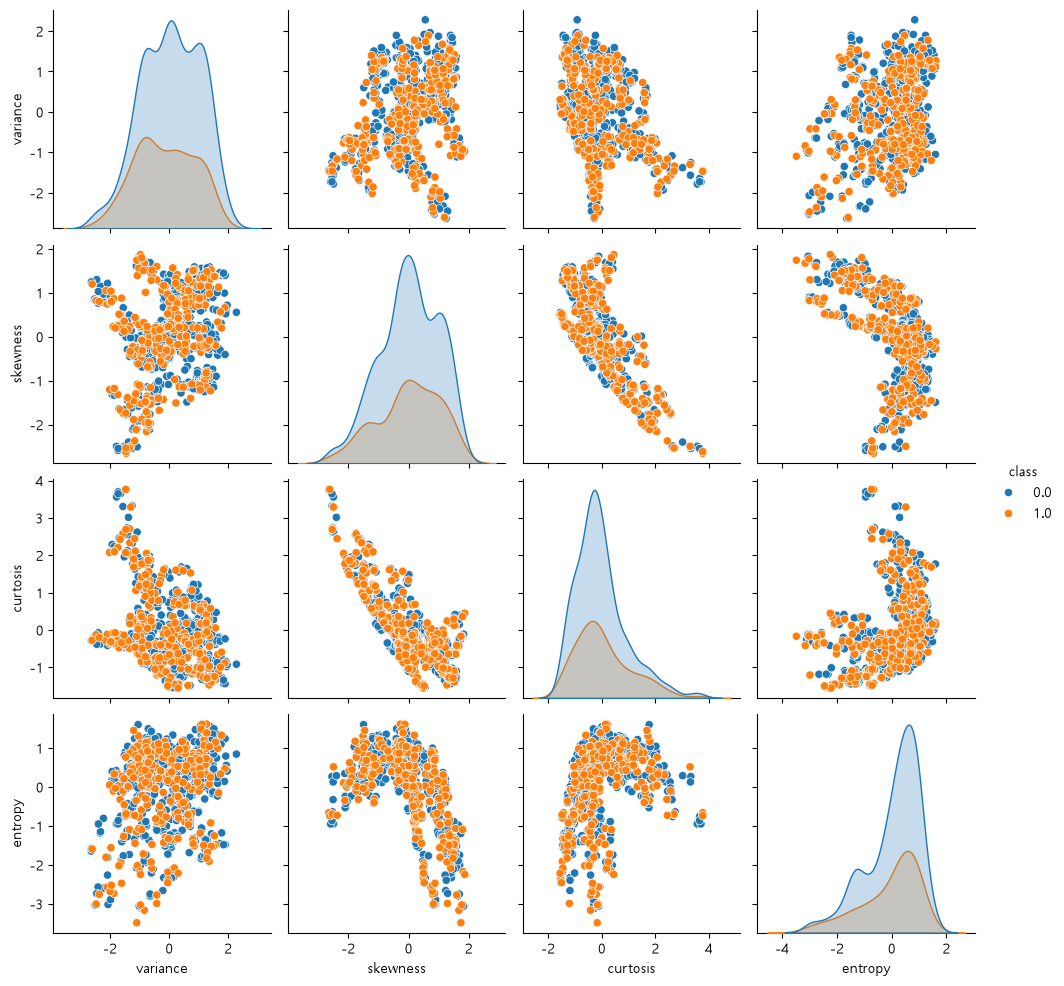

In [47]:
sns.pairplot(scaled_df, hue="class")
plt.show()

In [55]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [56]:
accuracy_score(y_pred, y_test)

1.0

In [57]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[153,   0],
       [  0, 122]])

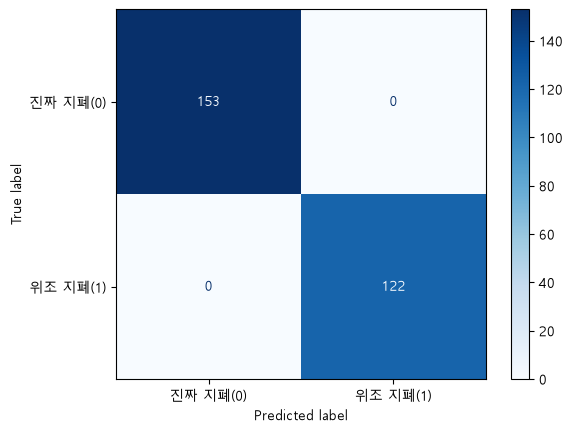

In [59]:
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["진짜 지폐(0)","위조 지폐(1)"])
cm_display.plot(cmap="Blues")
plt.show()

In [63]:
# 조화 평균
# 정밀도(precision)와 재현률(recall)
score = f1_score(y_test, y_pred)

In [64]:
print(f"F1-Score 점수: {score}")

F1-Score 점수: 1.0
